In [97]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random

In [98]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self): #Representation 
        return f"Value(data= {self.data})"
    
    def __add__(self,other): # Addition
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self.data) + (other.data), (self,other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self,other): # Multiplication
        other = other if isinstance(other,Value) else Value(other)
        out = Value((self.data) * (other.data), (self,other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self,other):    #raising to the power
        assert isinstance(other, (int,float))
        out = Value(self.data ** other, (self, ),f"**{other}")

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):  #negation
        return self * -1
    
    def __sub__(self,other):    #Subtraction
        return self + (-other)
    
    def __rmul__(self,other): #Fallback case for other * self
        return self * other
    
    def __radd__(self,other): #Fallback case for other + self
        return self + other
    
    def __truediv__(self,other):
        return self * other ** -1

    def tanh(self): #for tanh squashing function
        x = self.data
        n = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(n, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - n**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self): # Exponential
        x = self.data
        out = Value(math.exp(x), (self, ), label = 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [99]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [100]:
def lol():
    h = 0.001
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e' 
    d = e + c; d.label ='d'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label= 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    a.data += h
    e = a*b; e.label = 'e'
    d = e + c; d.label ='d'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label= 'L'
    L2 = L.data

    print((L2-L1)/h)
lol()


6.000000000000227


In [101]:
x1= Value(2.0, label= 'x1')
x2= Value(0.0, label= 'x2')
w1= Value(-3.0, label= 'w1')
w2= Value(1.0, label= 'w2')
b = Value(6.8813735870195432, label = 'b')


x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [102]:

o.backward()

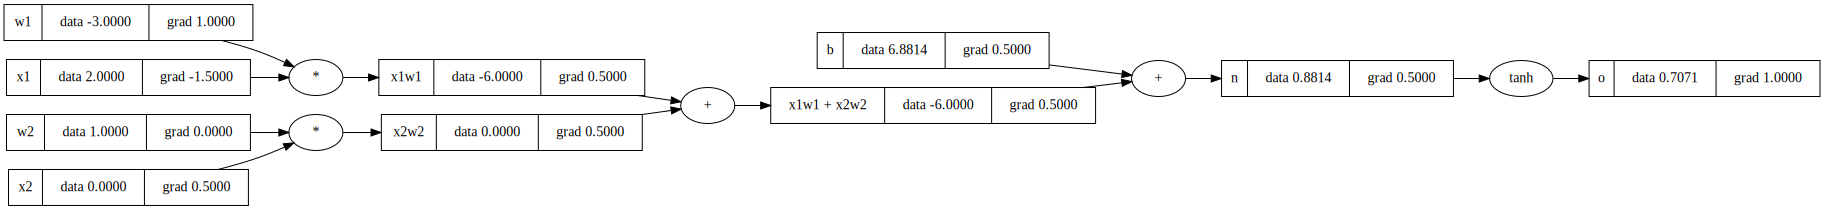

In [103]:
draw_dot(o)

In [104]:
x1= Value(2.0, label= 'x1')
x2= Value(0.0, label= 'x2')
w1= Value(-3.0, label= 'w1')
w2= Value(1.0, label= 'w2')
b = Value(6.8813735870195432, label = 'b')


x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

In [105]:
o.backward()

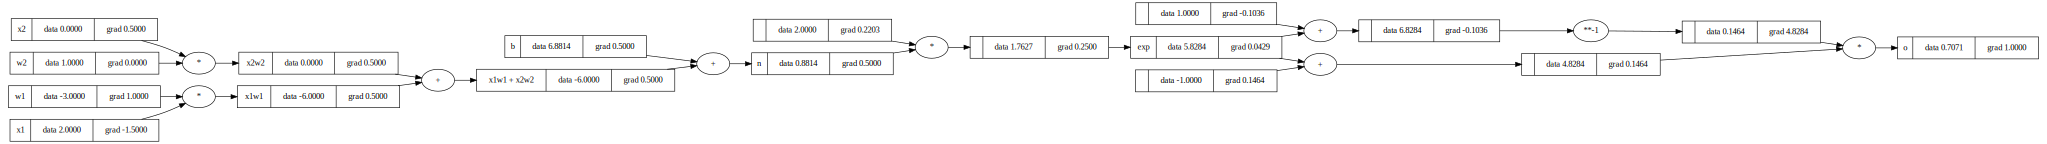

In [106]:
draw_dot(o)

In [107]:
#building a single neuron
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((xi * wi for xi,wi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
    
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [108]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data= 0.4808629978763355)

In [ ]:
xs = [[2.0, 3.0,-1.0], 
      [3.0,-1.0, 0.5],
      [0.5, 1.0, 1.0],
      [1.0, 1.0,-1.0]]

ys = [1.0, -1.0, -1.0, 1.0]
for k in range(20):
      ypred = [n(x) for x in xs]
      loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred,ys))
      
      for p in n.parameters():
            p.grad = 0.0
      loss.backward()

      for p in n.parameters():
            p.data += -0.1 * p.grad
      
      print(k, loss.data)

0 0.0007661917347401084
1 0.0007633920187866692
2 0.0007606124344938135
3 0.0007578527665050967
4 0.0007551128025173649
5 0.0007523923332268118
6 0.000749691152276344
7 0.0007470090562039683
8 0.0007443458443922571
9 0.0007417013190189112
10 0.000739075285008313
11 0.0007364675499840706
12 0.0007338779242226345
13 0.0007313062206076908
14 0.0007287522545857132
15 0.0007262158441221859
16 0.0007236968096589304
17 0.000721194974072171
18 0.000718710162631468
19 0.0007162422029594949


In [128]:
ypred

[Value(data= 0.9868152890978247),
 Value(data= -0.9934678542504924),
 Value(data= -0.9853845112340142),
 Value(data= 0.9830847949635813)]

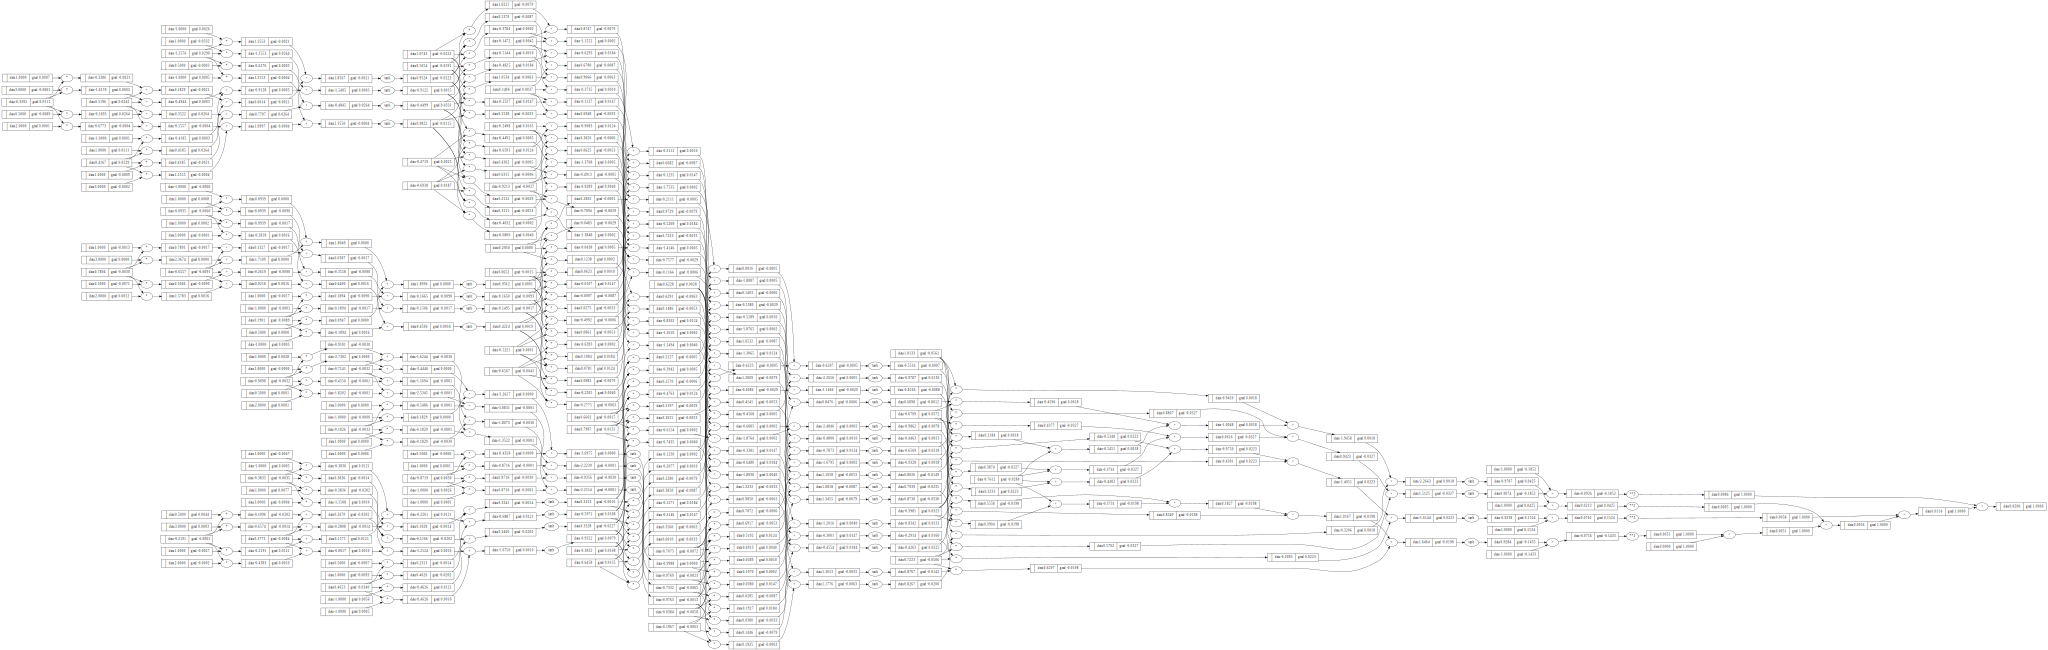

In [111]:
draw_dot(loss)